# ICLR dataset length and decision analysis

## Setup


In [59]:
from pathlib import Path
import re
import sqlite3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True

DB_PATH = Path("out_general/iclr2019.sqlite")

if not DB_PATH.exists():
    raise FileNotFoundError(
        f"Database not found: {DB_PATH.resolve()}\n"
        "Update DB_PATH to point to the SQLite database generated by ICLR_general_ingest.py."
    )

conn = sqlite3.connect(DB_PATH)
print(f"Using database: {DB_PATH.resolve()}")


Using database: /Users/verce/Desktop/Science des donnes-semsetre 6/Final Project/out_general/iclr2019.sqlite


## Check database schema and ingestion coverage


In [60]:
REQUIRED_TABLES = {
    "editions",
    "papers",
    "paper_pdf_text",
    "paper_decisions",
    "reviews",
}

tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type = 'table' ORDER BY name;",
    conn,
)

table_names = set(tables["name"])
missing = sorted(REQUIRED_TABLES - table_names)
if missing:
    raise RuntimeError(
        "This database does not match the expected ingestion schema. "
        f"Missing tables: {missing}"
    )

display(tables)


,name
0,editions
1,invitation_schemas
2,note_fields
3,notes
4,paper_decisions
5,paper_pdf_text
6,papers
7,reviews


In [61]:
coverage_query = """
SELECT
    e.year,
    COUNT(DISTINCT p.paper_id) AS n_papers,
    COUNT(DISTINCT CASE WHEN t.status = 'ok' THEN p.paper_id END) AS n_papers_with_pdf_text,
    COUNT(DISTINCT d.paper_id) AS n_papers_with_decision,
    COUNT(DISTINCT r.review_id) AS n_reviews,
    ROUND(1.0 * COUNT(DISTINCT CASE WHEN t.status = 'ok' THEN p.paper_id END) / COUNT(DISTINCT p.paper_id), 3) AS pdf_text_coverage,
    ROUND(1.0 * COUNT(DISTINCT d.paper_id) / COUNT(DISTINCT p.paper_id), 3) AS decision_coverage
FROM papers p
JOIN editions e ON e.edition_id = p.edition_id
LEFT JOIN paper_pdf_text t ON t.paper_id = p.paper_id
LEFT JOIN paper_decisions d ON d.paper_id = p.paper_id
LEFT JOIN reviews r ON r.paper_id = p.paper_id
GROUP BY e.year
ORDER BY e.year;
"""
coverage = pd.read_sql_query(coverage_query, conn)
display(coverage)


,year,n_papers,n_papers_with_pdf_text,n_papers_with_decision,n_reviews,pdf_text_coverage,decision_coverage
0,2019,1418,1418,1418,4329,1.0,1.0


In [62]:
pdf_status = pd.read_sql_query(
    """
    SELECT status, COUNT(*) AS n_papers
    FROM paper_pdf_text
    GROUP BY status
    ORDER BY n_papers DESC;
    """,
    conn,
)

display(pdf_status)


,status,n_papers
0,ok,1418


## Load analysis dataset


In [63]:
papers_query = """
SELECT
    p.paper_id,
    p.forum,
    p.edition_id,
    e.year,
    p.number,
    p.title,
    p.abstract,
    p.pdf_url,
    t.status AS pdf_text_status,
    t.n_chars,
    t.text AS pdf_text,
    d.decision AS raw_decision,
    d.decision_text
FROM papers p
JOIN editions e ON e.edition_id = p.edition_id
LEFT JOIN paper_pdf_text t ON t.paper_id = p.paper_id
LEFT JOIN paper_decisions d ON d.paper_id = p.paper_id
WHERE t.status = 'ok'
  AND t.text IS NOT NULL
  AND LENGTH(TRIM(t.text)) > 0
ORDER BY e.year, p.paper_id;
"""

papers = pd.read_sql_query(papers_query, conn)
print(f"Loaded {len(papers):,} papers with usable PDF text.")
display(papers.head(3))


Loaded 1,418 papers with usable PDF text.


,paper_id,forum,edition_id,year,number,title,abstract,pdf_url,pdf_text_status,n_chars,pdf_text,raw_decision,decision_text
0,B14ejsA5YQ,B14ejsA5YQ,ICLR.cc/2019/Conference,2019,594,Neural Causal Discovery with Learnable Input Noise,Learning causal relations from observational time series with nonlinear interactions and complex causal structures i...,/pdf/57a11848006e91d0eeb3c9006f26442258c407cd.pdf,ok,71070,Under review as a conference paper at ICLR 2019\nNEURAL CAUSAL DISCOVERY WITH LEARNABLE IN-\nPUT NOISE\nAnonymous au...,Reject,"Granger Causality is a beautiful operational definition of causality, that reduces causal modeling to the past-to-fu..."
1,B14rPj0qY7,B14rPj0qY7,ICLR.cc/2019/Conference,2019,262,RETHINKING SELF-DRIVING : MULTI -TASK KNOWLEDGE FOR BETTER GENERALIZATION AND ACCIDENT EXPLANATION ABILITY,Current end-to-end deep learning driving models have two problems: (1) Poor\ngeneralization ability of unobserved dr...,/pdf/71d4407475c16d3cd272915f752a8b6af7ce9efc.pdf,ok,32417,Under review as a conference paper at ICLR 2019\nRETHINKING SELF-DRIVING: MULTI-TASK KNOWL-\nEDGE FOR BETTER GENERAL...,Reject,"The paper presents a unified system for perception and control that is trained in a step-wise fashion, with visual d..."
2,B1EjKsRqtQ,B1EjKsRqtQ,ICLR.cc/2019/Conference,2019,478,Hierarchical Attention: What Really Counts in Various NLP Tasks,Attention mechanisms in sequence to sequence models have shown great ability and wonderful performance in various na...,/pdf/2de1a2d23536899248aea15fe0c19a5a9ea7cd65.pdf,ok,29365,Under review as a conference paper at ICLR 2019\nHIERARCHICAL ATTENTION: WHAT REALLY COUNTS\nIN VARIOUS NLP TASKS\nA...,Reject,The authors propose a hierarchical attention layer which combines intermediate layers of multi-level attention. Whil...


## Text cleaning and metrics


The PDF text extracted from each paper contains not only the main body of the article, but also page headers, page numbers, equations, references, appendices, and other formatting artifacts. Since the goal is to estimate the length of the actual paper body, the notebook applies a dedicated cleaning pipeline before computing `main_word_count`.

The cleaning process is as follows:

1. **Text normalization**  

2. **Back-matter removal**  

3. **Artifact removal**  

4. **Equation and math-heavy line removal**  

5. **Word and sentence statistics**  



In [64]:
WORD_RE = re.compile(r"\b[a-zA-Z]+(?:[-'][a-zA-Z]+)*\b")
SENTENCE_SPLIT_RE = re.compile(r"(?<=[.!?])\s+")

BACK_MATTER_PATTERNS = [
    r"^\s*(?:\d+\.?\s*)?references\s*$",
    r"^\s*(?:\d+\.?\s*)?bibliography\s*$",
    r"^\s*(?:\d+\.?\s*)?appendix\s*$",
    r"^\s*(?:\d+\.?\s*)?appendices\s*$",
    r"^\s*(?:\d+\.?\s*)?acknowledg(?:e)?ments?\s*$",
]


def normalize_text(text: str) -> str:
    if not isinstance(text, str):
        return ""

    text = text.replace("\x00", " ")
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)

    return text.strip()


def count_words(text: str) -> int:
 
    return len(WORD_RE.findall(normalize_text(text)))


def remove_back_matter(text: str, min_words_before_cut: int = 1500) -> str:
   
    text = normalize_text(text)
    lines = text.splitlines()

    char_pos = 0

    for line in lines:
        lower_line = line.lower().strip()

        for pattern in BACK_MATTER_PATTERNS:
            if re.match(pattern, lower_line):
                words_before = count_words(text[:char_pos])

                if words_before >= min_words_before_cut:
                    return text[:char_pos].strip()

        char_pos += len(line) + 1

    return text.strip()


def is_probable_page_artifact(line: str) -> bool:
    
    line = line.strip()

    if not line:
        return True

    # Standalone page number
    if re.fullmatch(r"\d{1,4}", line):
        return True

    # Common conference/header/footer artifacts
    lower = line.lower()
    artifact_phrases = [
        "published as a conference paper",
        "under review as a conference paper",
        "international conference on learning representations",
        "openreview",
    ]

    if len(line) < 120 and any(phrase in lower for phrase in artifact_phrases):
        return True

    return False


def is_math_heavy_line(line: str) -> bool:
    
    line = line.strip()

    if not line:
        return True

    # Very short lines usually do not contribute meaningful prose
    if len(line) < 3:
        return True

    words = WORD_RE.findall(line)
    word_count = len(words)

    if word_count == 0:
        return True

    math_symbol_count = len(re.findall(r"[=<>+\-*/^_{}\[\]\|\\∑∏∂∫√∞≈≠≤≥→←∈λμσθ]", line))
    digit_count = len(re.findall(r"\d", line))
    single_letter_vars = len(re.findall(r"\b[a-zA-Z]\b", line))

    symbol_ratio = math_symbol_count / max(len(line), 1)

    # Mostly mathematical symbols
    if symbol_ratio > 0.30:
        return True

    # Too many math indicators compared to natural-language words
    if math_symbol_count + digit_count + single_letter_vars > 2 * word_count:
        return True

    return False


def remove_repeated_short_lines(text: str, min_repetitions: int = 3) -> str:
    
    lines = [line.strip() for line in normalize_text(text).splitlines()]

    short_lines = [
        line for line in lines
        if line and len(line) <= 120
    ]

    counts = pd.Series(short_lines).value_counts()
    repeated = set(counts[counts >= min_repetitions].index)

    kept = [
        line for line in lines
        if line not in repeated
    ]

    return "\n".join(kept)


def remove_math_and_artifact_lines(text: str) -> str:
    
    text = remove_repeated_short_lines(text)

    kept_lines = []

    for line in normalize_text(text).splitlines():
        stripped = line.strip()

        if is_probable_page_artifact(stripped):
            continue

        if is_math_heavy_line(stripped):
            continue

        kept_lines.append(stripped)

    return "\n".join(kept_lines)


def extract_main_text(text: str) -> str:
   
    text = normalize_text(text)
    text = remove_back_matter(text)
    text = remove_math_and_artifact_lines(text)
    return normalize_text(text)


def split_sentences(text: str) -> list[str]:
    text = normalize_text(text)

    if not text:
        return []

    candidates = SENTENCE_SPLIT_RE.split(text)

    return [
        s.strip()
        for s in candidates
        if count_words(s) >= 3
    ]


def compute_sentence_stats(text: str) -> dict:
    sentences = split_sentences(text)
    lengths = np.array([count_words(s) for s in sentences], dtype=float)

    if len(lengths) == 0:
        return {
            "sentence_count": 0,
            "mean_sentence_length": np.nan,
            "median_sentence_length": np.nan,
            "p95_sentence_length": np.nan,
        }

    return {
        "sentence_count": int(len(lengths)),
        "mean_sentence_length": float(np.mean(lengths)),
        "median_sentence_length": float(np.median(lengths)),
        "p95_sentence_length": float(np.percentile(lengths, 95)),
    }

def count_syllables(word: str) -> int:
    """
    Simple syllable-count heuristic for English words.
    This is approximate but sufficient for dataset-level readability analysis.
    """
    word = word.lower()
    word = re.sub(r"[^a-z]", "", word)

    if not word:
        return 0

    vowels = "aeiouy"
    syllables = 0
    prev_was_vowel = False

    for char in word:
        is_vowel = char in vowels

        if is_vowel and not prev_was_vowel:
            syllables += 1

        prev_was_vowel = is_vowel

    # Basic silent-e correction
    if word.endswith("e"):
        syllables = max(1, syllables - 1)

    return max(1, syllables)


def flesch_reading_ease(text: str) -> float:
    """
    Compute an approximate Flesch Reading Ease score.

    Higher values indicate easier-to-read text.
    Lower values indicate denser or more complex text.
    """
    if not isinstance(text, str) or not text.strip():
        return np.nan

    sentences = split_sentences(text)
    words = WORD_RE.findall(normalize_text(text))

    if len(sentences) == 0 or len(words) == 0:
        return np.nan

    syllable_count = sum(count_syllables(word) for word in words)

    words_per_sentence = len(words) / len(sentences)
    syllables_per_word = syllable_count / len(words)

    return 206.835 - 1.015 * words_per_sentence - 84.6 * syllables_per_word

def normalize_decision_label(value: str) -> str:
    if value is None or pd.isna(value):
        return "Unknown"
    s = str(value).lower()

    if "withdraw" in s:
        return "Withdrawn"
    if "reject" in s or "decline" in s:
        return "Reject"
    if "accept" in s or "poster" in s or "spotlight" in s or "oral" in s:
        return "Accept"
    return "Other"

In [65]:
papers["abstract_word_count"] = papers["abstract"].map(count_words)
papers["full_word_count"] = papers["pdf_text"].map(count_words)

papers["main_text"] = papers["pdf_text"].map(extract_main_text)
papers["main_word_count"] = papers["main_text"].map(count_words)

papers["removed_word_count"] = papers["full_word_count"] - papers["main_word_count"]
papers["main_to_full_word_ratio"] = (papers["main_word_count"] / papers["full_word_count"].replace(0, np.nan))

# Normalize final decision labels from the paper_decisions table.
papers["decision_label"] = papers["raw_decision"].map(normalize_decision_label)

sentence_stats = papers["main_text"].apply(compute_sentence_stats).apply(pd.Series)
papers = pd.concat([papers.drop(columns=sentence_stats.columns, errors="ignore"), sentence_stats], axis=1)

papers["main_flesch_score"] = papers["main_text"].apply(flesch_reading_ease)

metric_cols = [
    "abstract_word_count",
    "full_word_count",
    "main_word_count",
    "removed_word_count",
    "main_to_full_word_ratio",
    "sentence_count",
    "mean_sentence_length",
    "median_sentence_length",
    "p95_sentence_length",
    "main_flesch_score"
]

summary = papers[metric_cols].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).round(2)

display(summary)

,abstract_word_count,full_word_count,main_word_count,removed_word_count,main_to_full_word_ratio,sentence_count,mean_sentence_length,median_sentence_length,p95_sentence_length,main_flesch_score
count,1418.00,1418.00,1418.00,1418.00,1418.00,1418.00,1418.00,1418.00,1418.00,1418.00
mean,161.93,7310.32,4667.66,2642.66,0.67,222.59,21.17,19.24,42.30,38.84
std,45.17,2412.08,771.88,2049.78,0.13,41.11,2.63,2.52,6.29,6.47
min,37.00,1705.00,1599.00,45.00,0.11,79.00,14.24,13.00,27.40,17.67
5%,95.00,4467.25,3455.30,659.00,0.44,158.00,17.11,15.00,33.33,28.39
25%,129.00,5745.25,4177.50,1323.00,0.59,197.00,19.46,18.00,38.00,34.76
50%,157.00,6898.50,4632.50,2165.00,0.68,222.00,20.98,19.00,41.55,38.81
75%,189.00,8389.50,5160.00,3356.00,0.77,248.00,22.68,21.00,46.00,42.75
95%,245.00,11332.50,5945.30,6087.05,0.87,289.15,25.93,24.00,53.03,49.69
max,339.00,31221.00,8995.00,25448.00,0.97,446.00,31.83,29.00,75.75,75.13


## Lexical diversity, repetition & citations


In [66]:
def ttr(text, cap=2000):
    w = WORD_RE.findall(text.lower()) if isinstance(text, str) else []
    w = w[:cap]
    return len(set(w)) / len(w) if w else np.nan

def rep_ngram(text, n=3):
    w = WORD_RE.findall(text.lower()) if isinstance(text, str) else []
    if len(w) < n + 1:
        return np.nan
    g = [tuple(w[i:i+n]) for i in range(len(w) - n + 1)]
    return 1 - len(set(g)) / len(g)

CITE_RE = re.compile(r"\[\d{1,3}(?:\s*[,-]\s*\d{1,3})*\]"
                     r"|\([A-Z][A-Za-z]+(?: et al\.?)?,?\s+\d{4}[a-z]?\)")

papers["ttr"]  = papers["main_text"].apply(ttr)
papers["rep3"] = papers["main_text"].apply(rep_ngram)
papers["n_citations"] = papers["main_text"].apply(
    lambda t: len(CITE_RE.findall(t)) if isinstance(t, str) else 0)
papers["has_citations"] = papers["n_citations"] > 0

display(papers[["ttr", "rep3", "n_citations"]]
        .describe(percentiles=[0.05, 0.5, 0.95]).round(3))
print("Papers with >=1 citation: %.1f%%" % (100 * papers["has_citations"].mean()))


,ttr,rep3,n_citations
count,1418.000,1418.000,1418.000
mean,0.296,0.113,14.457
std,0.028,0.035,10.586
min,0.144,0.045,0.000
5%,0.250,0.066,0.000
50%,0.296,0.107,13.000
95%,0.340,0.182,34.000
max,0.403,0.269,94.000


Papers with >=1 citation: 89.3%


## Final decision analysis


,decision_label,n_papers,%
0,Reject,916,64.6
1,Accept,502,35.4


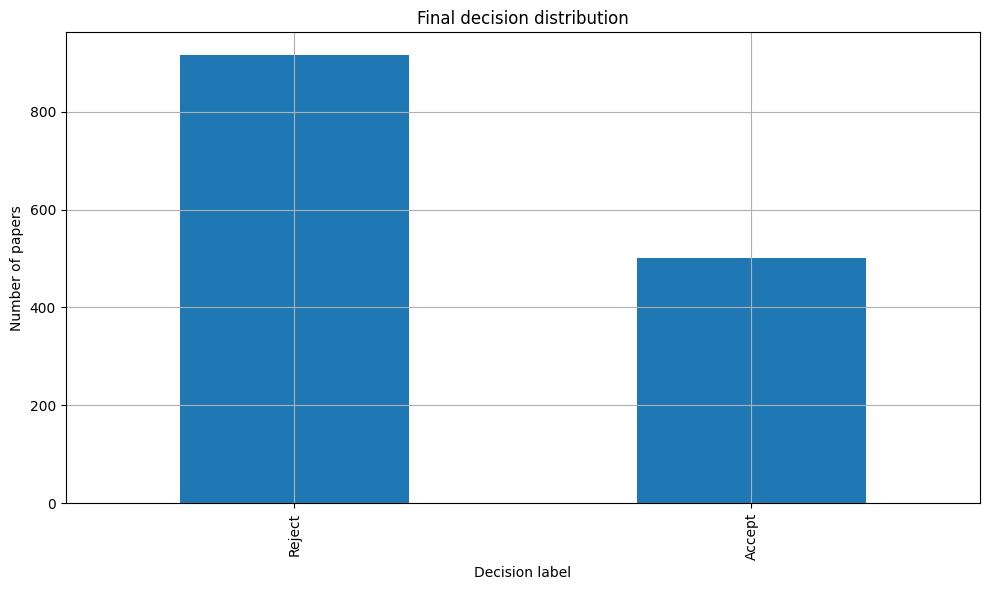

In [67]:
decision_counts = (
    papers["decision_label"]
    .value_counts(dropna=False)
    .rename_axis("decision_label")
    .reset_index(name="n_papers")
)
decision_counts["%"] = (100 * decision_counts["n_papers"] / decision_counts["n_papers"].sum()).round(1)

display(decision_counts)

ax = decision_counts.plot.bar(x="decision_label", y="n_papers", legend=False)
ax.set_title("Final decision distribution")
ax.set_xlabel("Decision label")
ax.set_ylabel("Number of papers")
plt.tight_layout()
plt.show()

## Review score coverage and relationship with decisions


In [68]:
reviews_query = """
SELECT
    r.paper_id,
    COUNT(*) AS review_count,
    AVG(r.rating) AS mean_rating,
    AVG(r.confidence) AS mean_confidence,
    MIN(r.rating) AS min_rating,
    MAX(r.rating) AS max_rating
FROM reviews r
GROUP BY r.paper_id;
"""

review_features = pd.read_sql_query(reviews_query, conn)

dataset = papers.merge(review_features, on="paper_id", how="left")
dataset["review_count"] = dataset["review_count"].fillna(0).astype(int)

review_coverage = pd.DataFrame({
    "metric": ["papers_with_reviews", "papers_with_numeric_rating", "papers_with_numeric_confidence"],
    "n_papers": [
        (dataset["review_count"] > 0).sum(),
        dataset["mean_rating"].notna().sum(),
        dataset["mean_confidence"].notna().sum(),
    ],
})
review_coverage["share_of_loaded_papers"] = (review_coverage["n_papers"] / len(dataset)).round(3)
display(review_coverage)


,metric,n_papers,share_of_loaded_papers
0,papers_with_reviews,1418,1.0
1,papers_with_numeric_rating,1418,1.0
2,papers_with_numeric_confidence,1418,1.0


### Review score by final decision

,n_papers,mean_review_count,median_review_count,mean_rating,median_rating,mean_confidence
decision_label,,,,,,
Reject,916,3.06,3.0,4.80,5.00,3.79
Accept,502,3.04,3.0,6.61,6.67,3.70


/var/folders/27/rq2dhm5d6wlg0zggr3qmyz3c0000gn/T/ipykernel_76579/3364505929.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["Accept", "Reject"])


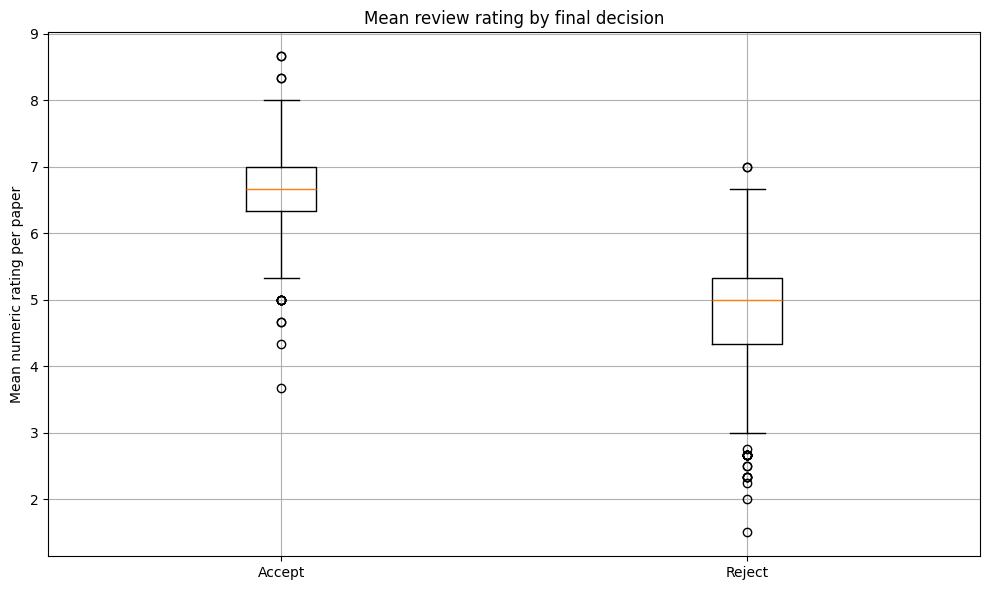

In [69]:
review_summary_by_decision = (
    dataset.groupby("decision_label")
    .agg(
        n_papers=("paper_id", "count"),
        mean_review_count=("review_count", "mean"),
        median_review_count=("review_count", "median"),
        mean_rating=("mean_rating", "mean"),
        median_rating=("mean_rating", "median"),
        mean_confidence=("mean_confidence", "mean"),
    )
    .round(2)
    .sort_values("n_papers", ascending=False)
)

display(review_summary_by_decision)

rating_df = dataset[dataset["decision_label"].isin(["Accept", "Reject"])].dropna(subset=["mean_rating"])
if len(rating_df) > 0 and rating_df["decision_label"].nunique() == 2:
    fig, ax = plt.subplots()
    data = [
        rating_df.loc[rating_df["decision_label"] == "Accept", "mean_rating"],
        rating_df.loc[rating_df["decision_label"] == "Reject", "mean_rating"],
    ]
    ax.boxplot(data, labels=["Accept", "Reject"])
    ax.set_title("Mean review rating by final decision")
    ax.set_ylabel("Mean numeric rating per paper")
    plt.tight_layout()
    plt.show()
else:
    print("Review-rating comparison skipped because both Accept and Reject labels with numeric ratings are not available.")


## Paper length analysis


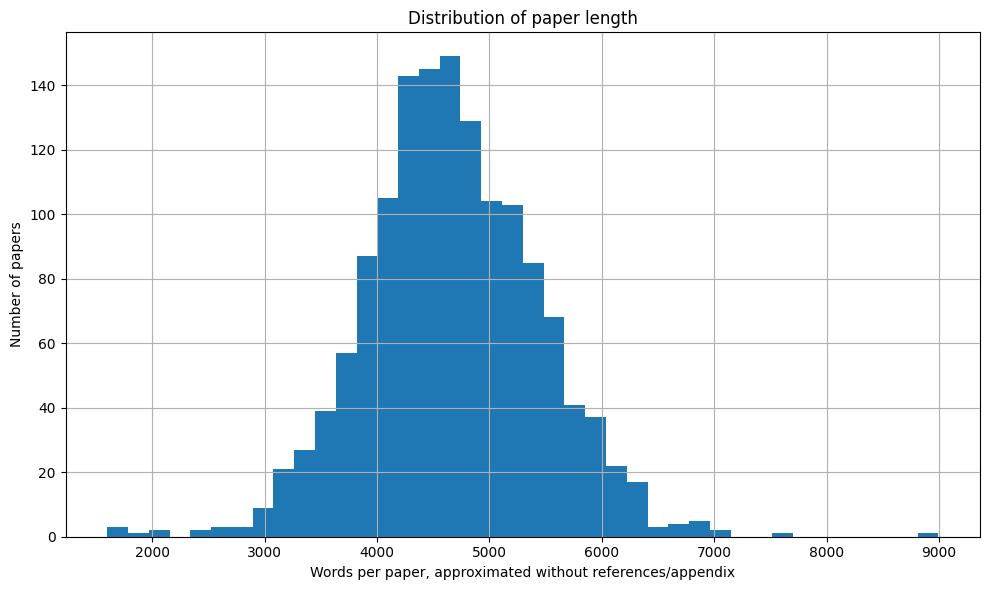

In [70]:
ax = papers["main_word_count"].plot.hist(bins=40)
ax.set_title("Distribution of paper length")
ax.set_xlabel("Words per paper, approximated without references/appendix")
ax.set_ylabel("Number of papers")
plt.tight_layout()
plt.show()


### Paper length by final decision 

,n_papers,mean,median,std,min,max
decision_label,,,,,,
Reject,916,4512.2,4462.0,779.5,1599,7683
Accept,502,4951.4,4889.5,671.2,3163,8995


/var/folders/27/rq2dhm5d6wlg0zggr3qmyz3c0000gn/T/ipykernel_76579/2374796901.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["Accept", "Reject"])


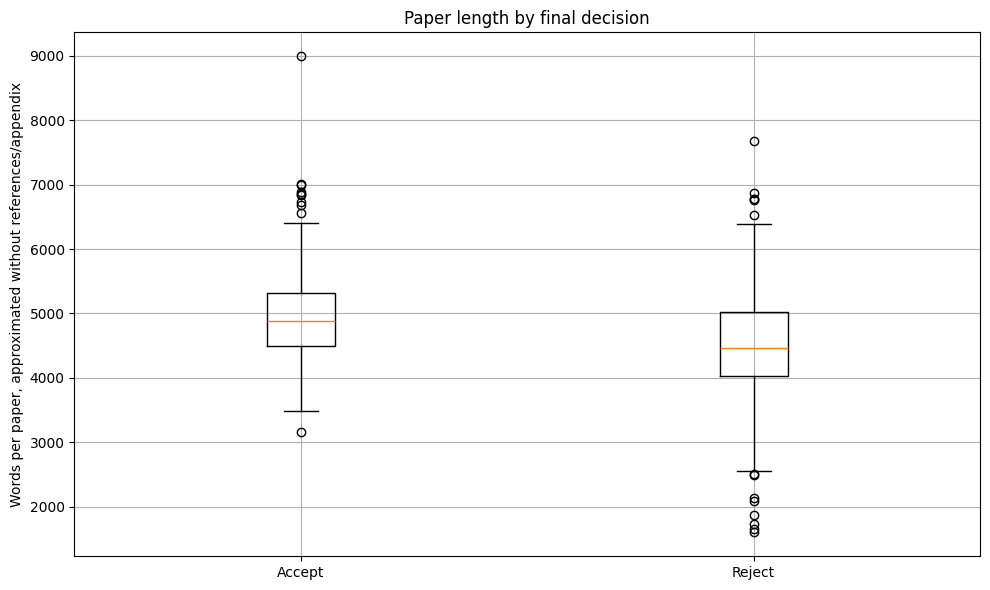

In [71]:
length_summary_by_decision = (
    papers.groupby("decision_label")["main_word_count"]
    .agg(n_papers="count", mean="mean", median="median", std="std", min="min", max="max")
    .round(1)
    .sort_values("n_papers", ascending=False)
)

display(length_summary_by_decision)

focus = papers[papers["decision_label"].isin(["Accept", "Reject"])].copy()
if len(focus) >= 2 and focus["decision_label"].nunique() == 2:
    fig, ax = plt.subplots()
    data = [
        focus.loc[focus["decision_label"] == "Accept", "main_word_count"].dropna(),
        focus.loc[focus["decision_label"] == "Reject", "main_word_count"].dropna(),
    ]
    ax.boxplot(data, labels=["Accept", "Reject"])
    ax.set_title("Paper length by final decision")
    ax.set_ylabel("Words per paper, approximated without references/appendix")
    plt.tight_layout()
    plt.show()
else:
    print("Accept/Reject comparison skipped because both labels are not available.")


### Length quantiles and outlier papers

In [72]:
quantiles = papers["main_word_count"].quantile([0.01, 0.05, 0.5, 0.95, 0.99]).round(0).astype(int)
display(quantiles.to_frame("main_word_count"))

outlier_cols = ["year", "paper_id", "title", "decision_label", "main_word_count", "full_word_count", "n_chars"]
print("Shortest extracted papers")
display(papers[outlier_cols].sort_values("main_word_count").head(10))
print("Longest extracted papers")
display(papers[outlier_cols].sort_values("main_word_count", ascending=False).head(10))


,main_word_count
0.01,2920
0.05,3455
0.50,4632
0.95,5945
0.99,6504


Shortest extracted papers


,year,paper_id,title,decision_label,main_word_count,full_word_count,n_chars
1175,2019,rJEyrjRqYX,Reduced-Gate Convolutional LSTM Design Using Predictive Coding for Next-Frame Video Prediction,Reject,1599,1766,10970
713,2019,HylJtiRqYQ,VECTORIZATION METHODS IN RECOMMENDER SYSTEM,Reject,1660,1705,11424
889,2019,SJlgOjAqYQ,A quantifiable testing of global translational invariance in Convolutional and Capsule Networks,Reject,1729,1954,14445
1158,2019,r1xkIjA9tX,q-Neurons: Neuron Activations based on Stochastic Jackson's Derivative Operators,Reject,1868,3290,25727
73,2019,B1lx42A9Ym,Neural Rendering Model: Joint Generation and Prediction for Semi-Supervised Learning,Reject,2092,18562,119312
878,2019,SJgiNo0cKX,Multiple Encoder-Decoders Net for Lane Detection,Reject,2133,2982,20703
936,2019,Ske25sC9FQ,Robustness and Equivariance of Neural Networks,Reject,2485,4030,28455
462,2019,HJMXus0ct7,iRDA Method for Sparse Convolutional Neural Networks,Reject,2513,4627,33355
1036,2019,SygJSiA5YQ,Weak contraction mapping and optimization,Reject,2560,3126,21345
660,2019,HyMuaiAqY7,Deli-Fisher GAN: Stable and Efficient Image Generation With Structured Latent Generative Space,Reject,2628,3059,20159


Longest extracted papers


,year,paper_id,title,decision_label,main_word_count,full_word_count,n_chars
294,2019,ByfyHh05tQ,Learning to Design RNA,Accept,8995,10181,78425
504,2019,HJgVisRqtX,SEGEN: SAMPLE-ENSEMBLE GENETIC EVOLUTIONARY NETWORK MODEL,Reject,7683,9220,65178
764,2019,S1VWjiRcKX,Universal Successor Features Approximators,Accept,7005,11513,73551
1257,2019,rke4HiAcY7,Caveats for information bottleneck in deterministic scenarios,Accept,7001,13122,80687
174,2019,BJxgz2R9t7,Learning To Solve Circuit-SAT: An Unsupervised Differentiable Approach,Accept,6891,9074,59437
738,2019,HyxUIj09KX,"S-System, Geometry, Learning, and Optimization: A Theory of Neural Networks",Reject,6866,20695,130964
162,2019,BJluy2RcFm,Janossy Pooling: Learning Deep Permutation-Invariant Functions for Variable-Size Inputs,Accept,6857,11253,79359
1007,2019,SyMDXnCcF7,A Mean Field Theory of Batch Normalization,Accept,6842,30276,212810
548,2019,Hk41X2AqtQ,Hierarchically-Structured Variational Autoencoders for Long Text Generation,Reject,6779,9859,65836
848,2019,SJMeTo09YQ,Guided Exploration in Deep Reinforcement Learning,Reject,6771,10070,66301


### Suspicious papers check

In [73]:
suspicious = papers[
    (papers["full_word_count"] > 3000)
    & (papers["main_to_full_word_ratio"] < 0.25)
].copy()

display(
    suspicious[
        [
            "paper_id",
            "title",
            "decision_label",
            "main_word_count",
            "full_word_count",
            "main_to_full_word_ratio",
            "n_chars",
        ]
    ].sort_values("main_to_full_word_ratio").head(20)
)

,paper_id,title,decision_label,main_word_count,full_word_count,main_to_full_word_ratio,n_chars
73,B1lx42A9Ym,Neural Rendering Model: Joint Generation and Prediction for Semi-Supervised Learning,Reject,2092,18562,0.112703,119312
857,SJeFNoRcFQ,Traditional and Heavy Tailed Self Regularization in Neural Network Models,Reject,5773,31221,0.184908,216862
1007,SyMDXnCcF7,A Mean Field Theory of Batch Normalization,Accept,6842,30276,0.225988,212810
436,H1xipsA5K7,Learning Two-layer Neural Networks with Symmetric Inputs,Accept,5837,24094,0.242259,142776


The suspicious papers were manually inspected to verify that the cleaning procedure had been applied correctly. Most cases were consistent: the cleaned main text ended at the conclusion or discussion section, indicating that the references and appendices had been removed as intended.

## Sentence-length analysis


,sentence_count,mean_sentence_length,median_sentence_length,p95_sentence_length
count,1418.00,1418.00,1418.00,1418.00
mean,222.59,21.17,19.24,42.30
std,41.11,2.63,2.52,6.29
min,79.00,14.24,13.00,27.40
5%,158.00,17.11,15.00,33.33
25%,197.00,19.46,18.00,38.00
50%,222.00,20.98,19.00,41.55
75%,248.00,22.68,21.00,46.00
95%,289.15,25.93,24.00,53.03
max,446.00,31.83,29.00,75.75


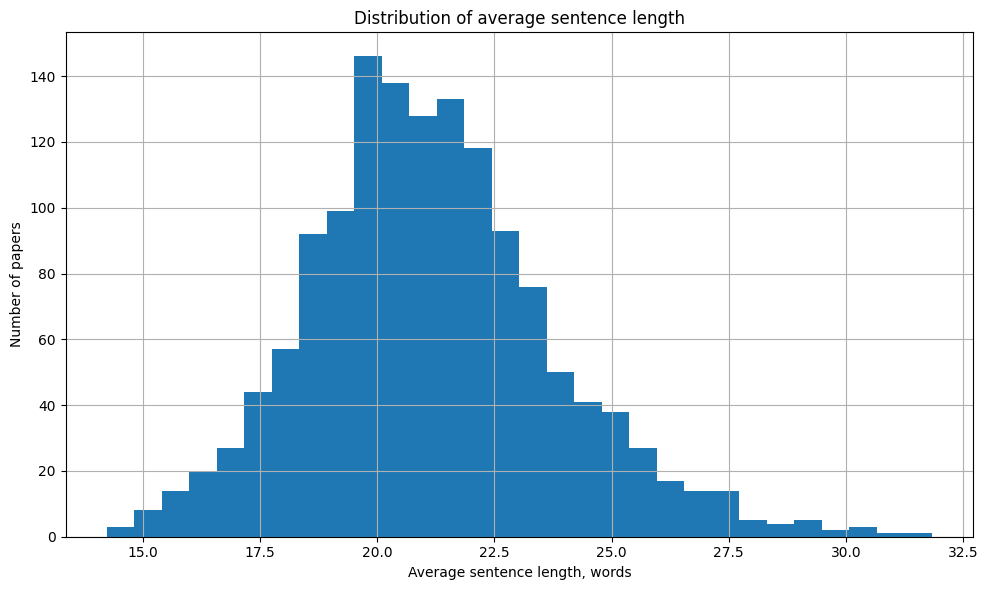

In [74]:
sentence_summary = papers[[
    "sentence_count",
    "mean_sentence_length",
    "median_sentence_length",
    "p95_sentence_length",
]].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).round(2)

display(sentence_summary)

ax = papers["mean_sentence_length"].dropna().plot.hist(bins=30)
ax.set_title("Distribution of average sentence length")
ax.set_xlabel("Average sentence length, words")
ax.set_ylabel("Number of papers")
plt.tight_layout()
plt.show()


### Readability by final decision

- using the Flesch readibility score

,n_papers,mean,median,std,min,max
decision_label,,,,,,
Reject,916,39.11,39.02,6.57,21.09,75.13
Accept,502,38.34,38.30,6.28,17.67,55.55


/var/folders/27/rq2dhm5d6wlg0zggr3qmyz3c0000gn/T/ipykernel_76579/2156382581.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=["Accept", "Reject"])


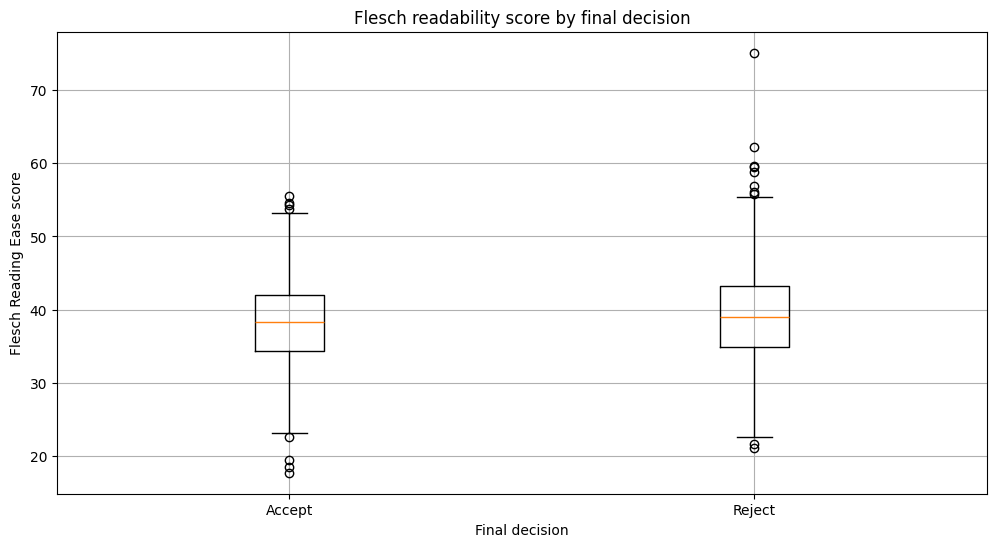

In [75]:
flesch_summary_by_decision = (
    papers.groupby("decision_label")["main_flesch_score"]
    .agg(n_papers="count", mean="mean", median="median", std="std", min="min", max="max")
    .round(2)
    .sort_values("n_papers", ascending=False)
)

display(flesch_summary_by_decision)

plot_df = papers[
    papers["decision_label"].isin(["Accept", "Reject"])
    & papers["main_flesch_score"].notna()
].copy()

data = [
    plot_df.loc[plot_df["decision_label"] == "Accept", "main_flesch_score"],
    plot_df.loc[plot_df["decision_label"] == "Reject", "main_flesch_score"],
]

fig, ax = plt.subplots(figsize=(12, 6))

ax.boxplot(data, labels=["Accept", "Reject"])

ax.set_title("Flesch readability score by final decision")
ax.set_xlabel("Final decision")
ax.set_ylabel("Flesch Reading Ease score")

plt.show()

The Flesch readability scores are very similar for accepted and rejected papers. Both groups have median scores around the same range, indicating that papers are generally difficult to read, as expected for technical research papers. The large overlap between the two distributions suggests that this simple readability metric alone does not strongly distinguish accepted from rejected submissions.

### Correlation between metrics

In [76]:
combined_cols = [
    "main_word_count",
    "sentence_count",
    "mean_sentence_length",
    "review_count",
    "mean_rating",
    "mean_confidence",
]

corr_df = dataset[combined_cols].dropna(how="all")
if len(corr_df) > 1:
    corr = corr_df.corr(numeric_only=True).round(3)
    display(corr)
else:
    print("Correlation table skipped because there are not enough numeric observations.")


,main_word_count,sentence_count,mean_sentence_length,review_count,mean_rating,mean_confidence
main_word_count,1.000,0.759,0.191,0.040,0.342,-0.108
sentence_count,0.759,1.000,-0.478,0.028,0.280,-0.081
mean_sentence_length,0.191,-0.478,1.000,0.020,0.036,-0.022
review_count,0.040,0.028,0.020,1.000,-0.010,-0.046
mean_rating,0.342,0.280,0.036,-0.010,1.000,-0.133
mean_confidence,-0.108,-0.081,-0.022,-0.046,-0.133,1.000


## ICLR reference profile

Single summary of the real-ICLR values for every metric that also exists on the generated
papers. This is the baseline to compare each generator model against (matches vs differs).


In [77]:
ref_cols = [
    "main_word_count",
    "abstract_word_count",
    "mean_sentence_length",
    "ttr",
    "rep3",
    "n_citations",
    "main_flesch_score"
]

iclr_reference = papers[ref_cols].agg(["mean", "median", "std"]).round(3).T
iclr_reference.index.name = "metric"

display(iclr_reference)

,mean,median,std
metric,,,
main_word_count,4667.661,4632.500,771.875
abstract_word_count,161.933,157.000,45.167
mean_sentence_length,21.167,20.976,2.630
ttr,0.296,0.296,0.028
rep3,0.113,0.107,0.035
n_citations,14.457,13.000,10.586
main_flesch_score,38.841,38.808,6.474
